
<h2 id="3.1-DSSD-Energy-Calibration">3.1 DSSD Energy Calibration</h2><h3 id="DSSD-%E6%8E%A2%E6%B5%8B%E5%99%A8">DSSD 探测器</h3><ul>
<li><p>Detectors: S4</p>
</li>
<li><p>128(Pie) x 128(Ring)</p>
</li>
<li><p>Pie: $1.4^{\circ}$/条, HV=-110V</p>
</li>
<li><p>Ring: 0.43 mm 条宽，~0.03 mm 条间距, HV=0V</p>
</li>
<li><p>厚度1014 $\mu$m
<img alt="" src="fig/s4.png"/></p>
</li>
</ul>
<h3 id="%E6%94%BE%E5%B0%84%E6%BA%90">放射源</h3><ul>
<li><p>$\alpha-$Sources: $^{232}U$</p>
</li>
<li><p>$\alpha$粒子从Pie面入射，考虑放射源表面的金膜和Si前表面的死层后，最终沉积在Si里的能量分别为 $5.5658$ MeV, $6.1748$ MeV, $6.6708$ MeV, $8.6931$ MeV.</p>
</li>
<li><p>使用下图中标红色的4个峰进行刻度.</p>
</li>
</ul>
<p><img alt="" src="fig/alpha.png"/></p>
<ul>
<li>数据: s4.root</li>
<li>数据是用Digital modules的自触发模式记录的, 数据截取了pie和ring的前48条信息。</li>
</ul>
<div class="highlight"><pre><span></span><span class="w"> </span><span class="n">Int_t</span><span class="w"> </span><span class="n">pe</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span><span class="c1">//Pie 0-47</span>
<span class="w"> </span><span class="n">Int_t</span><span class="w"> </span><span class="n">re</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span><span class="c1">//Ring 0-47</span>
</pre></div>


In [ ]:
TFile *f = new TFile("s4.root");
TTree *tree = (TTree*)f->Get("tree");
TCanvas *c1 = new TCanvas;

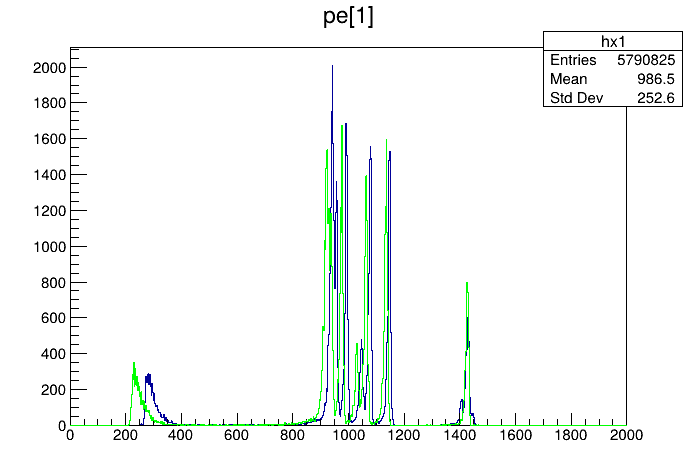

In [3]:
tree->Draw("pe[0]>>hx0(1000, 0, 2000)");//单条
tree->Draw("pe[1]>>hx1(1000, 0, 2000)");//单条
TH1 *hx0 = (TH1*)gROOT->FindObject("hx0");
TH1 *hx1 = (TH1*)gROOT->FindObject("hx1");
hx0->SetLineColor(kGreen);
hx1->Draw("hist");
hx0->Draw("same");
c1->Draw();

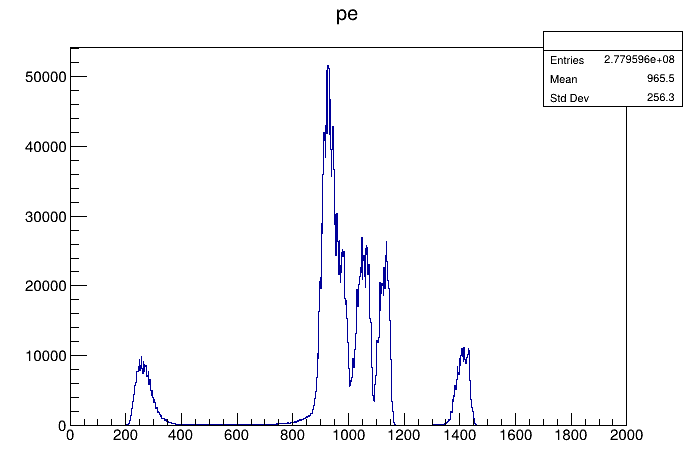

In [4]:
tree->Draw("pe>>(1000,0,2000)");//所有条pe[0-47]累积
c1->Draw();

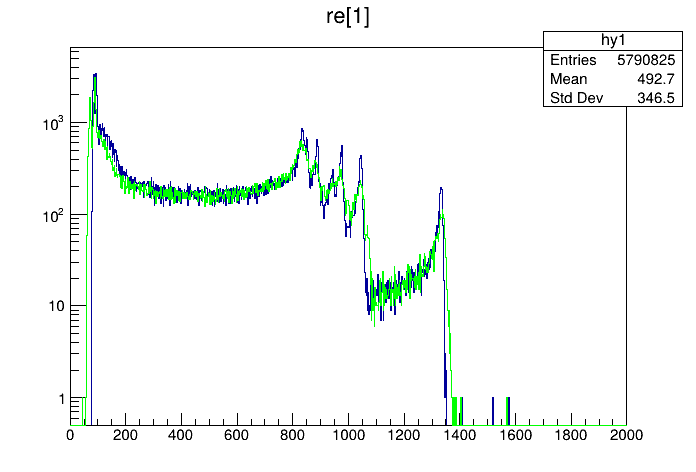

In [5]:
tree->Draw("re[0]>>hy0(1000, 0, 2000)");//单条
tree->Draw("re[1]>>hy1(1000, 0, 2000)");//单条
TH1 *hy0 = (TH1*)gROOT->FindObject("hy0");
TH1 *hy1 = (TH1*)gROOT->FindObject("hy1");
gPad->SetLogy();
hy0->SetLineColor(kGreen);
hy1->Draw();
hy0->Draw("same");
c1->Draw();


<h3 id="TSpectrum">TSpectrum</h3><p><code>TSpectrum</code> 用于一维谱分析中的几个核心问题：本底估计、平滑、反卷积和寻峰。在刻度问题中，最直接相关的是本底估计和寻峰。()</p>
<p>创建对象时需要先给出允许搜索的最大峰数，例如：</p>
<div class="highlight"><pre><code class="language-cpp">TSpectrum *s = new TSpectrum(500);</code></pre></div>
<p>这个数字不是实际峰数，而是允许搜索的上限。()</p>
<h3 id="Background">Background</h3><p>用于本底估计的接口可以写成：</p>
<div class="highlight"><pre><code class="language-cpp">TH1 *TSpectrum::Background(const TH1 *h,
                           Int_t niter = 20,
                           Option_t *option = "");</code></pre></div>
<p>niter 是迭代次数，控制 clipping 窗口覆盖的尺度，不是简单的平滑强度。窗口需要跨过待分离的峰。将估计本底叠加在原谱上检查；本底扣除后的谱用于寻找候选峰，峰位拟合仍使用原始计数谱。</p>
<p><strong>先由 <code>Background</code> 构造本底，再从原谱中减去本底，得到更适合后续寻峰的谱。</strong></p>
<p>接口与参数说明：<a href="https://root.cern.ch/doc/master/classTSpectrum.html">ROOT TSpectrum reference</a>。</p>

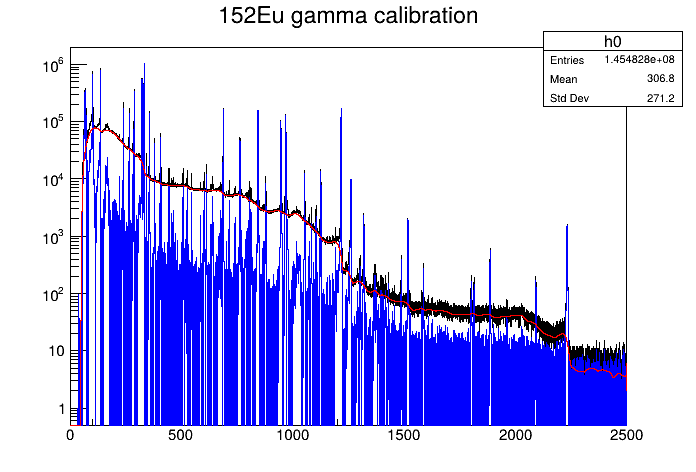

In [7]:
TFile *fgamma = new TFile("gamma.root");
TH1F *h0 = (TH1F*)fgamma->Get("h0");

TSpectrum *s = new TSpectrum(500);
TH1F *hbg = (TH1F*)s->Background(h0, 30, "same");
TH1F *hpeak  = (TH1F*)h0->Clone("hh");
hpeak->Add(hbg, -1);
hpeak->SetName("hpeak");
c1->Clear();
h0->SetLineColor(kBlack);
hbg->SetLineColor(kRed);
hpeak->SetLineColor(kBlue);
h0->Draw("hist");
hpeak->Draw("hist same");
hbg->Draw("hist same");
gPad->SetLogy();
c1->Draw();


<h3 id="Search">Search</h3><p>用于自动找峰的接口可以写成：</p>
<div class="highlight"><pre><span></span><span class="n">Int_t</span><span class="w"> </span><span class="n">TSpectrum</span><span class="o">::</span><span class="n">Search</span><span class="p">(</span><span class="k">const</span><span class="w"> </span><span class="n">TH1</span><span class="w"> </span><span class="o">*</span><span class="n">hin</span><span class="p">,</span>
<span class="w">                        </span><span class="n">Double_t</span><span class="w"> </span><span class="n">sigma</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">2</span><span class="p">,</span>
<span class="w">                        </span><span class="n">Option_t</span><span class="w"> </span><span class="o">*</span><span class="n">option</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="s">""</span><span class="p">,</span>
<span class="w">                        </span><span class="n">Double_t</span><span class="w"> </span><span class="n">threshold</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mf">0.05</span><span class="p">);</span>
</pre></div>
<p>sigma 以 bin 为单位描述预期峰宽；threshold 是相对于搜索结果中最高峰的阈值。它们控制候选峰集，不能独立判断某个结构是否为真实谱线。</p>
<p><code>Search</code> 默认包含本底处理。上一步已显式扣除本底，所以这里用 <code>nobackground</code>，避免重复扣除；<code>nodraw</code> 关闭自动绘图，由 <code>hist</code> 画谱，再显式叠加候选峰标记。hist 只改变显示，不删除直方图误差。参见 <a href="https://root.cern.ch/doc/master/classTSpectrum.html">TSpectrum::Search</a>。</p><p>自动寻峰给的是候选位置，不是精确 centroid。后面仍沿用“识别谱线 → 局部拟合 centroid → 能量刻度 → residual 检查”的顺序。</p>

22
0: 332, 984052
1: 135, 786091
2: 101, 664539
3: 322, 538447
4: 67, 355974
5: 71, 117777
6: 63, 71649.2
7: 96, 61243.9
8: 59, 57259.4
9: 94, 43959.7
10: 98, 39411.4
11: 87, 29171.4
12: 132, 17675.6
13: 168, 23274.4
14: 104, 18971.5
15: 78, 18438.1
16: 160, 17473.4
17: 129, 19779
18: 165, 11409.6
19: 161, 12014.4
20: 106, 12859.6
21: 121, 10732.4

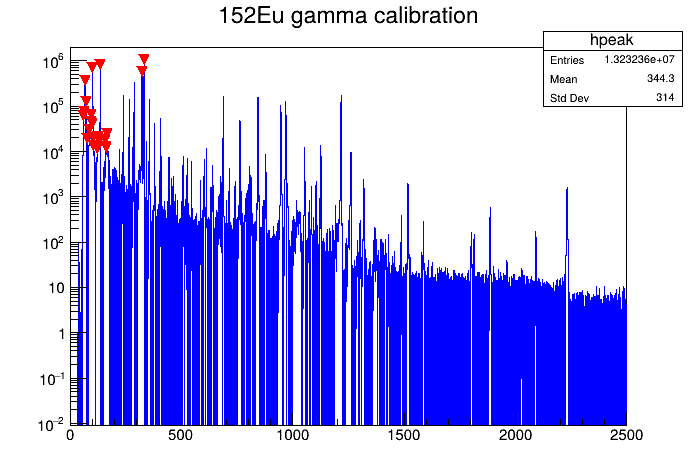

In [9]:
Double_t *xpeaks = nullptr;
Double_t *ypeaks = nullptr;

Int_t nfound = s->Search(hpeak, 2, "nobackground nodraw", 0.01);

xpeaks = s->GetPositionX();
ypeaks = s->GetPositionY();

cout << nfound << endl;
for(int i=0; i<nfound; i++)
    cout << i << ": " << int(xpeaks[i]) 
         << ", " << ypeaks[i] << endl;
hpeak->Draw("hist");
TPolyMarker *peakMarkers=(TPolyMarker*)hpeak->GetListOfFunctions()->FindObject("TPolyMarker");
if(peakMarkers) peakMarkers->Draw();
c1->Draw();

<h3>保存与排序候选峰</h3><p><code>vector&lt;Double_t&gt;</code> 存候选位置，<code>push_back</code> 添加一个值。下面的 helper 用 <code>multimap&lt;Double_t,Double_t&gt;</code> 保存“峰高、峰位”，反向遍历得到峰高从大到小的序列；允许相同峰高，避免漏掉等高峰。实际对应哪条 α 谱线，还要结合能谱判断。</p><pre><code class="language-cpp">vector&lt;Double_t&gt; pe;
pe.push_back(993.0);
pe.push_back(1079.0);
// 若要按位置从小到大排列：
sort(pe.begin(),pe.end());</code></pre>

<h3>可重复调用的寻峰函数</h3><p>函数只在直方图副本上扣本底，保留原始计数用于后面的峰拟合。<code>backsub=0</code> 表示输入已经扣过本底。</p><pre><code class="language-cpp">#include &lt;TSpectrum.h&gt;
#include &lt;TH1.h&gt;
#include &lt;TROOT.h&gt;
#include &lt;TPolyMarker.h&gt;
#include &lt;TLatex.h&gt;
#include &lt;TString.h&gt;
#include &lt;map&gt;
#include &lt;vector&gt;
#include &lt;iostream&gt;
using namespace std;
TH1 *h = nullptr, *hb = nullptr;

void peaks(TString hname, vector&lt;Double_t&gt; &amp;pe, Double_t thres=0.05, int backsub=1)
{
  Int_t nfound;
  Double_t *xpeaks = NULL, *ypeaks = NULL;
  pe.clear();

  multimap&lt;Double_t, Double_t&gt; me;   // key: ypeaks, value: xpeaks

  TH1 *source = dynamic_cast&lt;TH1*&gt;(gROOT-&gt;FindObject(hname));
  h = source ? static_cast&lt;TH1*&gt;(source-&gt;Clone(hname+"_search")) : nullptr;
  if(!h) {
    cout &lt;&lt; "Histogram " &lt;&lt; hname &lt;&lt; " not found." &lt;&lt; endl;
    return;
  }

  TSpectrum *sp = new TSpectrum(500);

  if(backsub) {
    hb = (TH1F*)sp-&gt;Background(h, 80);
    h-&gt;Add(hb, -1);
  }

  // 本底已在上面处理，不再使用 Search 的默认本底扣除。
  nfound = sp-&gt;Search(h, 2, "nobackground nodraw", thres);
  h-&gt;Draw("hist");

  TPolyMarker *pm = (TPolyMarker*)h-&gt;GetListOfFunctions()-&gt;FindObject("TPolyMarker");
  if(pm) {
    pm-&gt;SetMarkerStyle(32);
    pm-&gt;SetMarkerColor(kGreen);
    pm-&gt;SetMarkerSize(0.4);
    pm-&gt;Draw(); // HIST 不画附加对象，显式叠加候选峰标记
  }

  xpeaks = sp-&gt;GetPositionX();
  ypeaks = sp-&gt;GetPositionY();

  for(int j=0; j&lt;nfound; j++) {
    me.emplace(ypeaks[j], xpeaks[j]);

    TLatex *tex = new TLatex(xpeaks[j], ypeaks[j], Form("%.0f", xpeaks[j]));
    tex-&gt;SetTextFont(42);
    tex-&gt;SetTextSize(0.025);
    tex-&gt;SetTextAlign(12);
    tex-&gt;SetTextAngle(90);
    tex-&gt;SetTextColor(kRed);
    tex-&gt;Draw();
  }

  for(auto ie = me.rbegin(); ie != me.rend(); ++ie) {
    cout &lt;&lt; ie-&gt;second &lt;&lt; " " &lt;&lt; ie-&gt;first &lt;&lt; endl;
    pe.push_back(ie-&gt;second);
  }

  delete sp;
}</code></pre>

In [12]:
cout<<hpeak->GetName()<<endl;

hpeak

332.7 984052
135.9 786091
101.7 664539
322.9 538447
67.1 355974
71.9 117777
63.3 71649.2
96.7 61243.9
59.5 57259.4

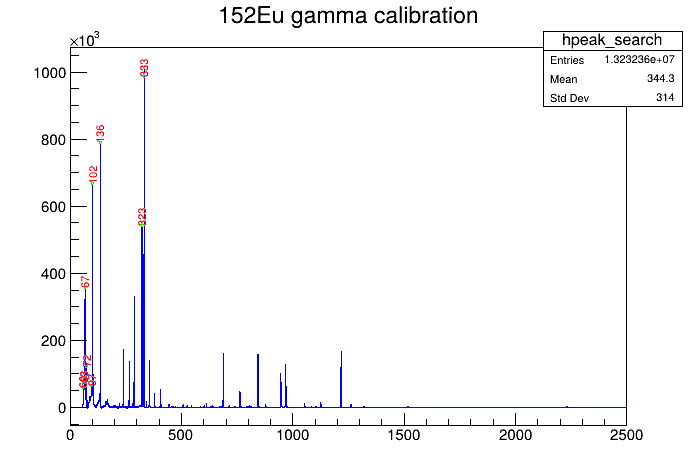

In [13]:
gROOT->ProcessLine(".L peaks.C");
vector<Double_t> ge;
peaks("hpeak", ge, 0.05, 0); // 已扣除本底，不重复扣除
gPad->SetLogy(0);
c1->Draw();


<h2 id="DSSD-Energy-Calibration">DSSD Energy Calibration</h2><p>对某一条 Pie 谱执行：</p>


In [ ]:
TFile *fs4 = new TFile("s4.root");
TTree *tree = (TTree*)fs4->Get("tree");
tree->Draw("pe[1]>>hx1(1000, 0, 2000)");//单条
vector<Double_t> pe;
Double_t e[4] = {5.5658, 6.1748, 6.6708, 8.6931};//alpha energy

941 1750.87
1079 1558.92
993 1549.89
1147 1493.96
957 1358.88
1429 604
1047 479.911
277 238.968
1405 133
915 119.867

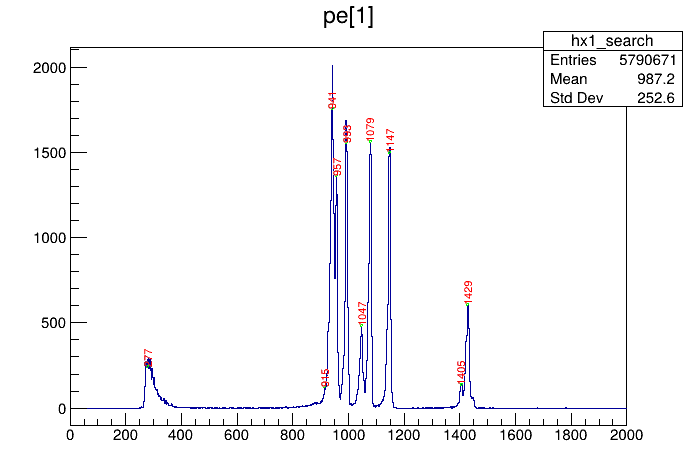

In [16]:
peaks("hx1", pe);
gPad->SetLogy(0);
c1->Draw();

<p>寻峰给出候选位置，不会自动识别核素。本例中先按峰高取前六个候选，再按 channel 排序，选取与四个已知能量相符的峰组。这个选择只适用于当前示例谱。</p><h3>候选峰与已知能量的匹配</h3><p>推广到其他条时，可比较不同峰组的线性刻度残差，同时检查峰序、能量覆盖和预期谱线；最小残差本身不能排除误认峰。最终峰心由原始谱的局部拟合确定。</p>

In [18]:
if (pe.size() < 6) throw std::runtime_error("候选峰不足六个，请检查寻峰结果");
sort(pe.begin(), pe.begin()+6); 
Double_t mpe[4], cpe[4];//peak,count
for(int i=0; i<4; i++) {
    mpe[i] = pe[2+i];
    cpe[i] = hx1->GetBinContent(hx1->FindBin(mpe[i]));
    cout << mpe[i] << " " << cpe[i] << endl;
}

993 1550
1079 1559
1147 1494
1429 604


<h2 id="%E7%B2%97%E5%88%BB%E5%BA%A6">粗刻度</h2><p>选定 4 个候选峰位以后，可以先做一轮峰位—能量线性拟合，得到粗刻度关系：</p>


****************************************
Minimizer is Linear / Migrad
Chi2                      =  4.40562e-05
NDf                       =            2
p0                        =     -1.56557   +/-   0.0168397
p1                        =   0.00717874   +/-   1.43506e-05

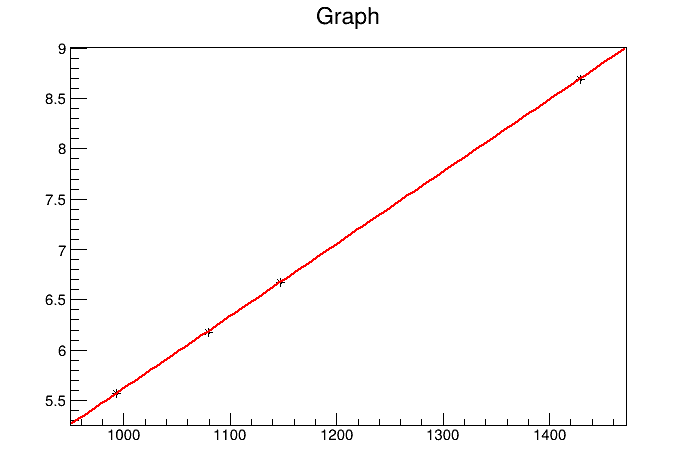

In [20]:
TGraph *gr = new TGraph(4, mpe, e);
gr->Draw("A*");
gr->Fit("pol1");
TF1 *f1 = gr->GetFunction("pol1");
c1->Draw();


<h3 id="%E9%80%9A%E8%BF%87%E6%AE%8B%E5%B7%AE%E5%9B%BE%E8%AF%84%E4%BC%B0%E6%8B%9F%E5%90%88%E7%BB%93%E6%9E%9C">通过残差图评估拟合结果</h3><h2 id="Residual-Plot">Residual Plot</h2><p>得到线性拟合后，还要快速检查拟合是否自然。这里引入残差</p>
<p>$$
e_i = y_i - f(x_i|\alpha).
$$</p>
<p>如果模型和匹配都合理，残差应当围绕 0 随机分布，不应表现出明显的系统趋势。</p>


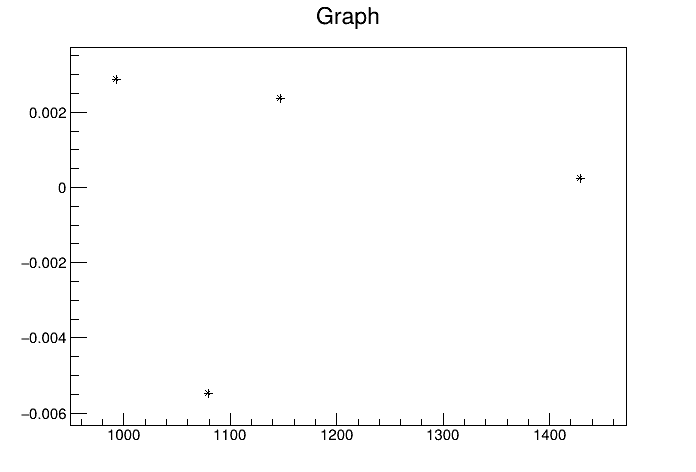

In [22]:
Double_t p0 = f1->GetParameter(0);
Double_t p1 = f1->GetParameter(1);
Double_t dpe[4];
for(int i=0; i<4; i++) 
    dpe[i] = e[i] - (p0 + p1 * mpe[i]);
TGraph *rgr = new TGraph(4,mpe,dpe);
rgr->Draw("A*");
c1->Draw();


<h2 id="Gaussian-Fit">Gaussian Fit</h2><p>粗刻度之后，不能直接把 <code>TSpectrum</code> 返回的峰位当作最终峰心。更合理的做法是对每个峰分别进行高斯拟合，用拟合得到的均值作为最终峰位。</p>
<p>在每个峰附近设置初值：</p>
<p>本例选取彼此分开的 α 峰，窄区间内先用 Gaussian 描述峰心。若局部本底或低能尾明显，应检查残差后调整模型和区间。下面的 <code>S</code> 返回拟合结果，<code>Q</code> 减少日志，<code>+</code> 保留前面各峰的曲线。</p>

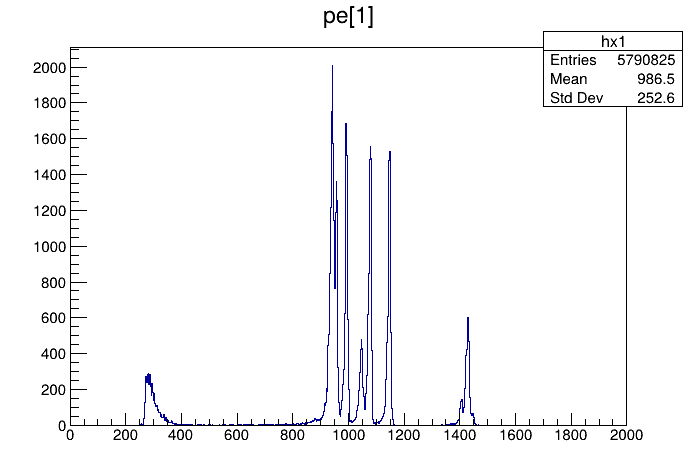

In [24]:
hx1->Draw("hist");
c1->Draw();

peaks = 992.9, sigma = 3.98, chi2/ndf = 12.91
peaks = 1078.3, sigma = 4.00, chi2/ndf = 11.31
peaks = 1147.3, sigma = 3.98, chi2/ndf = 13.35
peaks = 1429.0, sigma = 4.83, chi2/ndf = 1.27

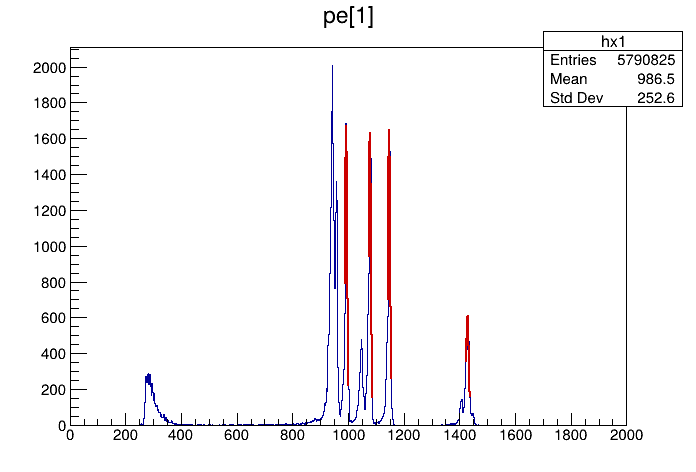

In [25]:
double par[4][3];//peak,sigma,chi2/ndf
double centroid[4], centroidError[4];
TF1 *fg[4];
TFitResultPtr fr;
for(int i=0; i<4; i++) {
    fg[i] = new TF1(Form("fg%d", i), "gaus");
    fg[i]->SetParameters(cpe[i], mpe[i], 4);
    fg[i]->SetRange(mpe[i]-5,mpe[i]+8);
    fg[i]->SetLineColor(kRed+1);
    fg[i]->SetLineWidth(2);
    fg[i]->SetParLimits(2, 0.2, 20);//constant,mean, sigma
    fr = hx1->Fit(fg[i], "SQ+", "", mpe[i]-5, mpe[i]+8);//superimpose TF1 to hx1
    if (int(fr) != 0 || !fr.Get() || !fr->IsValid()) throw std::runtime_error("峰拟合失败");
    par[i][0] = fg[i]->GetParameter(1);
    par[i][1] = fg[i]->GetParameter(2);
    par[i][2] = fr->Chi2()/fr->Ndf();
    centroid[i] = par[i][0];
    centroidError[i] = fg[i]->GetParError(1);
    cout << Form("peaks = %4.1f, sigma = %.2f, chi2/ndf = %.2f", 
                 par[i][0], par[i][1], par[i][2]) << endl;
}
hx1->Draw("hist");
for(int i=0;i<4;++i) fg[i]->Draw("same");
c1->Draw();

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      16.6311
NDf                       =            2
Edm                       =  1.88825e-08
NCalls                    =           42
p0                        =     -1.55384   +/-   0.00292773
p1                        =   0.00716924   +/-   2.65536e-06

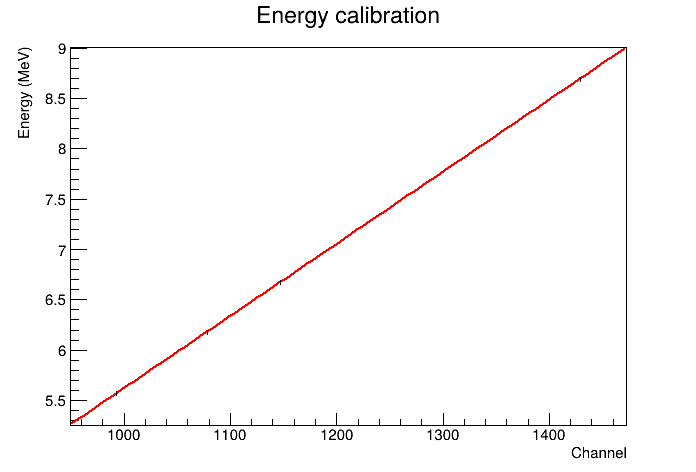

In [26]:
TGraphErrors *gr1 = new TGraphErrors(4, centroid, e, centroidError, nullptr);
gr1->SetTitle("Energy calibration;Channel;Energy (MeV)");
gr1->Draw("AP");
TFitResultPtr calibrationFit = gr1->Fit("pol1", "S");
TF1 *f2 = gr1->GetFunction("pol1");
c1->Draw();

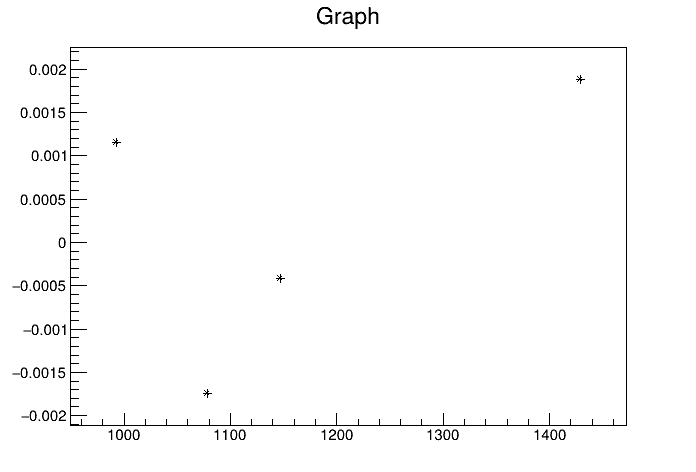

In [27]:
p0 = f2->GetParameter(0);
p1 = f2->GetParameter(1);
for(int i=0; i<4; i++) 
    dpe[i] = e[i] - (p0 + p1 * centroid[i]);
TGraph *rgr1 = new TGraph(4, centroid, dpe);
rgr1->Draw("A*");
c1->Draw();

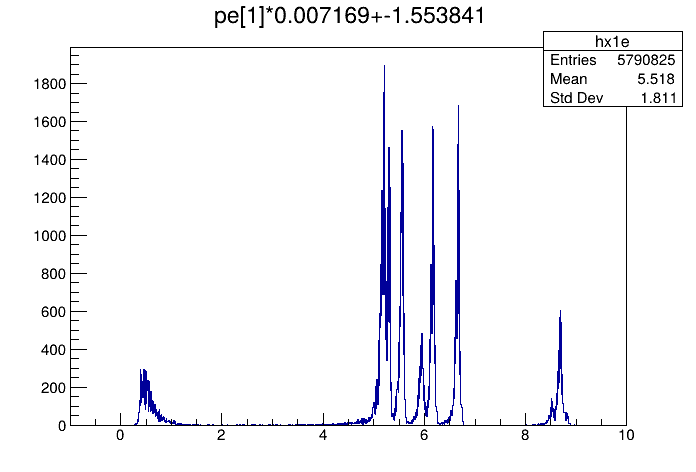

In [28]:
tree->Draw(Form("pe[1]*%f+%f>>hx1e(1000, -1, 10)", p1, p0));//单条
hx1e->Draw("hist");
c1->Draw();// bin 宽度应与原始 ADC 步距和刻度斜率相称；不必随机改变道值。